# AquaPlant — Phase F: Calibration & Uncertainty Evaluation

This notebook evaluates confidence reliability for the two final Phase-C/Phase-D models:

- **ResNet50 Fine-tuned**
- **EfficientNet-B0 Fine-tuned**

## Scientific protocol

- Validation set (**161 images**) is used **only to fit one scalar temperature** per model.
- Locked Test set (**157 images**) is used **only for final calibration/uncertainty evaluation**.
- Neural-network weights are **never retrained or tuned** in this phase.
- Temperature scaling does **not** change predicted class labels; it rescales logits/confidence.

## Main outputs

- Expected Calibration Error (ECE)
- Negative Log-Likelihood (NLL)
- Multiclass Brier Score
- Mean confidence / confidence gap
- Temperature scaling
- Reliability diagrams
- Predictive entropy analysis
- Error-detection AUROC
- Per-image calibrated outputs
- Final Phase-F artifact ZIP

In [1]:
# ============================================================
# CELL 1 — ENVIRONMENT
# ============================================================

import os
import json
import random
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet50, efficientnet_b0

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
)

from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_CLASSES = 14
ECE_BINS = 15

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("=" * 76)
print("PHASE F — CALIBRATION & UNCERTAINTY EVALUATION")
print("=" * 76)
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
print("Device  :", DEVICE)

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

print("\nKaggle inputs:")
for item in os.listdir("/kaggle/input"):
    print(" -", item)

print("\n✅ PHASE F ENVIRONMENT READY")
print("✅ Temperature scaling will be fitted on Validation only")
print("🔒 Locked Test will NOT be used to fit temperature")
print("🔒 Neural-network weights will NOT be updated")


PHASE F — CALIBRATION & UNCERTAINTY EVALUATION
PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda
GPU     : Tesla T4

Kaggle inputs:
 - datasets

✅ PHASE F ENVIRONMENT READY
✅ Temperature scaling will be fitted on Validation only
🔒 Locked Test will NOT be used to fit temperature
🔒 Neural-network weights will NOT be updated


In [2]:
# ============================================================
# CELL 2 — FIND VALIDATION, TEST, AND FINE-TUNED CHECKPOINTS
# ============================================================

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
)

def count_images_recursive(folder):
    total = 0
    for root, dirs, files in os.walk(folder):
        total += sum(
            1 for file in files
            if file.lower().endswith(IMAGE_EXTENSIONS)
        )
    return total

def count_direct_folders(folder):
    try:
        return len([
            d for d in os.listdir(folder)
            if os.path.isdir(os.path.join(folder, d))
        ])
    except Exception:
        return 0

VAL_DIR = None
TEST_DIR = None

for root, dirs, files in os.walk("/kaggle/input"):
    if count_direct_folders(root) == 14:
        n_images = count_images_recursive(root)

        if n_images == 161 and VAL_DIR is None:
            VAL_DIR = root

        if n_images == 157 and TEST_DIR is None:
            TEST_DIR = root

ALL_FILES = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        ALL_FILES.append(os.path.join(root, file))

def find_checkpoint(model_word, stage_word="finetuned"):
    candidates = []

    for path in ALL_FILES:
        name = os.path.basename(path).lower()

        if not name.endswith(".pth"):
            continue

        if (
            model_word.lower() in name
            and stage_word.lower() in name
            and "best" in name
        ):
            candidates.append(path)

    return candidates[0] if candidates else None

RESNET_FINETUNED_PTH = find_checkpoint("resnet50", "finetuned")
EFFNET_FINETUNED_PTH = find_checkpoint("efficientnet", "finetuned")

# ZIP fallback if Kaggle input contains artifact ZIPs rather than direct .pth files
if RESNET_FINETUNED_PTH is None or EFFNET_FINETUNED_PTH is None:
    EXTRACT_ROOT = "/kaggle/working/phaseF_extracted"
    os.makedirs(EXTRACT_ROOT, exist_ok=True)

    for path in list(ALL_FILES):
        if not path.lower().endswith(".zip"):
            continue

        filename = os.path.basename(path).lower()

        if "resnet" not in filename and "efficientnet" not in filename:
            continue

        target = os.path.join(EXTRACT_ROOT, Path(path).stem)
        os.makedirs(target, exist_ok=True)

        try:
            with zipfile.ZipFile(path, "r") as z:
                z.extractall(target)
        except Exception:
            pass

    for root, dirs, files in os.walk(EXTRACT_ROOT):
        for file in files:
            ALL_FILES.append(os.path.join(root, file))

    RESNET_FINETUNED_PTH = RESNET_FINETUNED_PTH or find_checkpoint(
        "resnet50", "finetuned"
    )
    EFFNET_FINETUNED_PTH = EFFNET_FINETUNED_PTH or find_checkpoint(
        "efficientnet", "finetuned"
    )

print("=" * 76)
print("PHASE F RESOURCE DETECTION")
print("=" * 76)

print("\nValidation:")
print(VAL_DIR)

print("\nLocked Test:")
print(TEST_DIR)

print("\nResNet50 Fine-tuned:")
print(RESNET_FINETUNED_PTH)

print("\nEfficientNet-B0 Fine-tuned:")
print(EFFNET_FINETUNED_PTH)

assert VAL_DIR is not None, "❌ Validation folder with 161 images was not found."
assert TEST_DIR is not None, "❌ Test folder with 157 images was not found."
assert count_images_recursive(VAL_DIR) == 161
assert count_images_recursive(TEST_DIR) == 157
assert RESNET_FINETUNED_PTH is not None, "❌ ResNet50 fine-tuned checkpoint not found."
assert EFFNET_FINETUNED_PTH is not None, "❌ EfficientNet-B0 fine-tuned checkpoint not found."

print("\n✅ Validation = 161 images")
print("✅ Locked Test = 157 images")
print("✅ ResNet50 fine-tuned checkpoint found")
print("✅ EfficientNet-B0 fine-tuned checkpoint found")


PHASE F RESOURCE DETECTION

Validation:
/kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Validation

Locked Test:
/kaggle/input/datasets/srabondcosta/aqua-plant-final-dataset/AquPlantDS_FINAL/Test

ResNet50 Fine-tuned:
/kaggle/input/datasets/srabondcosta/resnet50/resnet50_finetuned_best.pth

EfficientNet-B0 Fine-tuned:
/kaggle/input/datasets/srabondcosta/efficientnetb0/efficientnet_b0_finetuned_best.pth

✅ Validation = 161 images
✅ Locked Test = 157 images
✅ ResNet50 fine-tuned checkpoint found
✅ EfficientNet-B0 fine-tuned checkpoint found


In [3]:
# ============================================================
# CELL 3 — VALIDATION + TEST DATALOADERS
# Deterministic evaluation preprocessing only
# ============================================================

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

assert val_dataset.class_to_idx == test_dataset.class_to_idx, \
    "❌ Validation/Test class mappings do not match."

CLASS_NAMES = test_dataset.classes

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("=" * 76)
print("DATASET VERIFICATION")
print("=" * 76)
print("Validation images :", len(val_dataset))
print("Test images       :", len(test_dataset))
print("Classes           :", len(CLASS_NAMES))

print("\nClass mapping:")
for cls, idx in test_dataset.class_to_idx.items():
    print(f"{idx:2d} -> {cls}")

assert len(val_dataset) == 161
assert len(test_dataset) == 157
assert len(CLASS_NAMES) == 14

with open("/kaggle/working/phaseF_class_mapping.json", "w") as f:
    json.dump(test_dataset.class_to_idx, f, indent=2)

print("\n✅ Validation/Test mapping verified")
print("✅ Deterministic evaluation transform ready")


DATASET VERIFICATION
Validation images : 161
Test images       : 157
Classes           : 14

Class mapping:
 0 -> Class_10_lippia_alba
 1 -> Class_11_marsilea_minuta
 2 -> Class_12_duck_weeds
 3 -> Class_13_topapana
 4 -> Class_14_kachuripana
 5 -> Class_1_water_iris
 6 -> Class_2_pistia_stratiotes
 7 -> Class_3_lily_leaf
 8 -> Class_4_lotus-leaf
 9 -> Class_5_water_popy
10 -> Class_6_salvania
11 -> Class_7_chinese_water_spinach
12 -> Class_8_water_plantain
13 -> Class_9_mexican_sword_lily

✅ Validation/Test mapping verified
✅ Deterministic evaluation transform ready


In [4]:
# ============================================================
# CELL 4 — CHECKPOINT UTILITIES + EXACT ARCHITECTURES
# ============================================================

def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location
        )

def extract_state_dict(checkpoint):
    if not isinstance(checkpoint, dict):
        return checkpoint

    for key in [
        "model_state_dict",
        "state_dict",
        "model",
        "weights",
    ]:
        if key in checkpoint and isinstance(checkpoint[key], dict):
            return checkpoint[key]

    if all(isinstance(k, str) for k in checkpoint.keys()):
        if any(
            k.endswith(".weight") or k.endswith(".bias")
            for k in checkpoint.keys()
        ):
            return checkpoint

    raise RuntimeError("Could not identify model state_dict.")

def remove_module_prefix(state_dict):
    clean = {}

    for key, value in state_dict.items():
        if key.startswith("module."):
            key = key[len("module."):]
        clean[key] = value

    return clean

def build_resnet50():
    model = resnet50(weights=None)

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, NUM_CLASSES)
    )

    return model

def build_efficientnet_b0():
    model = efficientnet_b0(weights=None)

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, NUM_CLASSES)
    )

    return model

def load_model(model, checkpoint_path):
    checkpoint = safe_torch_load(
        checkpoint_path,
        map_location=DEVICE
    )

    state_dict = extract_state_dict(checkpoint)
    state_dict = remove_module_prefix(state_dict)

    model.load_state_dict(
        state_dict,
        strict=True
    )

    model = model.to(DEVICE)
    model.eval()

    return model

resnet_model = load_model(
    build_resnet50(),
    RESNET_FINETUNED_PTH
)

effnet_model = load_model(
    build_efficientnet_b0(),
    EFFNET_FINETUNED_PTH
)

print("✅ ResNet50 Fine-tuned loaded")
print("✅ EfficientNet-B0 Fine-tuned loaded")
print("✅ Both models are in evaluation mode")


✅ ResNet50 Fine-tuned loaded
✅ EfficientNet-B0 Fine-tuned loaded
✅ Both models are in evaluation mode


In [5]:
# ============================================================
# CELL 5 — OPTIONAL CHECKPOINT CLASS-MAPPING VERIFICATION
# ============================================================

def extract_checkpoint_class_mapping(path):
    checkpoint = safe_torch_load(path, map_location="cpu")

    if not isinstance(checkpoint, dict):
        return None

    if "class_to_idx" in checkpoint:
        return checkpoint["class_to_idx"]

    if "classes" in checkpoint:
        classes = checkpoint["classes"]

        if isinstance(classes, (list, tuple)):
            return {
                cls: idx
                for idx, cls in enumerate(classes)
            }

    return None

for model_name, checkpoint_path in {
    "ResNet50": RESNET_FINETUNED_PTH,
    "EfficientNet-B0": EFFNET_FINETUNED_PTH,
}.items():

    checkpoint_mapping = extract_checkpoint_class_mapping(checkpoint_path)

    if checkpoint_mapping is None:
        print(
            f"ℹ️ {model_name}: checkpoint has no class mapping metadata; "
            "using the verified ImageFolder mapping."
        )
    else:
        assert checkpoint_mapping == test_dataset.class_to_idx, \
            f"❌ {model_name} checkpoint class mapping differs from Test mapping."

        print(f"✅ {model_name}: checkpoint class mapping verified")

print("\n✅ Class-order verification step complete")


✅ ResNet50: checkpoint class mapping verified
✅ EfficientNet-B0: checkpoint class mapping verified

✅ Class-order verification step complete


In [6]:
# ============================================================
# CELL 6 — COLLECT RAW LOGITS ON VALIDATION AND TEST
# ============================================================

@torch.no_grad()
def collect_logits(model, loader):
    model.eval()

    logits_list = []
    labels_list = []

    for images, labels in loader:
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        logits = model(images)

        logits_list.append(
            logits.detach().cpu()
        )

        labels_list.append(
            labels.detach().cpu()
        )

    logits = torch.cat(logits_list, dim=0)
    labels = torch.cat(labels_list, dim=0)

    return logits, labels

MODEL_OBJECTS = {
    "ResNet50_Finetuned": resnet_model,
    "EfficientNetB0_Finetuned": effnet_model,
}

raw_outputs = {}

for model_name, model in MODEL_OBJECTS.items():
    print(f"\nCollecting logits for {model_name}...")

    val_logits, val_labels = collect_logits(
        model,
        val_loader
    )

    test_logits, test_labels = collect_logits(
        model,
        test_loader
    )

    raw_outputs[model_name] = {
        "val_logits": val_logits,
        "val_labels": val_labels,
        "test_logits": test_logits,
        "test_labels": test_labels,
    }

    print("Validation logits:", tuple(val_logits.shape))
    print("Test logits      :", tuple(test_logits.shape))

    assert val_logits.shape == (161, NUM_CLASSES)
    assert test_logits.shape == (157, NUM_CLASSES)

print("\n✅ Raw logits collected for both models")



Validation logits: (161, 14)
Test logits      : (157, 14)

Validation logits: (161, 14)
Test logits      : (157, 14)

✅ Raw logits collected for both models


In [7]:
# ============================================================
# CELL 7 — CALIBRATION / UNCERTAINTY METRIC FUNCTIONS
# ============================================================

def softmax_numpy(logits):
    return torch.softmax(
        logits,
        dim=1
    ).numpy()

def expected_calibration_error(
    probabilities,
    labels,
    n_bins=15
):
    confidences = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float64)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0
    rows = []

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 0:
            mask = (
                (confidences >= lower)
                & (confidences <= upper)
            )
        else:
            mask = (
                (confidences > lower)
                & (confidences <= upper)
            )

        count = int(mask.sum())

        if count == 0:
            rows.append({
                "bin": i + 1,
                "lower": lower,
                "upper": upper,
                "count": 0,
                "mean_confidence": np.nan,
                "accuracy": np.nan,
                "gap": np.nan,
            })
            continue

        bin_conf = float(confidences[mask].mean())
        bin_acc = float(accuracies[mask].mean())
        gap = abs(bin_conf - bin_acc)

        ece += (
            count / len(labels)
        ) * gap

        rows.append({
            "bin": i + 1,
            "lower": lower,
            "upper": upper,
            "count": count,
            "mean_confidence": bin_conf,
            "accuracy": bin_acc,
            "gap": gap,
        })

    return float(ece), pd.DataFrame(rows)

def multiclass_brier_score(
    probabilities,
    labels,
    num_classes
):
    one_hot = np.eye(
        num_classes
    )[labels]

    return float(
        np.mean(
            np.sum(
                (probabilities - one_hot) ** 2,
                axis=1
            )
        )
    )

def predictive_entropy(probabilities):
    clipped = np.clip(
        probabilities,
        1e-12,
        1.0
    )

    return -np.sum(
        clipped * np.log(clipped),
        axis=1
    )

def calculate_metrics(
    logits,
    labels,
    n_bins=15
):
    labels_np = labels.numpy()

    probabilities = softmax_numpy(logits)

    predictions = probabilities.argmax(axis=1)
    confidences = probabilities.max(axis=1)

    accuracy = accuracy_score(
        labels_np,
        predictions
    )

    macro_f1 = f1_score(
        labels_np,
        predictions,
        average="macro",
        zero_division=0
    )

    nll = float(
        F.cross_entropy(
            logits,
            labels
        ).item()
    )

    brier = multiclass_brier_score(
        probabilities,
        labels_np,
        NUM_CLASSES
    )

    ece, reliability_df = expected_calibration_error(
        probabilities,
        labels_np,
        n_bins=n_bins
    )

    mean_confidence = float(
        confidences.mean()
    )

    confidence_gap = (
        mean_confidence
        - accuracy
    )

    entropy = predictive_entropy(
        probabilities
    )

    incorrect = (
        predictions != labels_np
    ).astype(int)

    # Error-detection AUROC:
    # higher entropy should indicate a greater probability of error.
    if len(np.unique(incorrect)) == 2:
        error_detection_auroc = roc_auc_score(
            incorrect,
            entropy
        )
    else:
        error_detection_auroc = np.nan

    correct_mask = (
        predictions == labels_np
    )

    incorrect_mask = ~correct_mask

    mean_entropy_correct = (
        float(entropy[correct_mask].mean())
        if correct_mask.any()
        else np.nan
    )

    mean_entropy_incorrect = (
        float(entropy[incorrect_mask].mean())
        if incorrect_mask.any()
        else np.nan
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "nll": nll,
        "brier": brier,
        "ece": ece,
        "mean_confidence": mean_confidence,
        "confidence_gap": confidence_gap,
        "error_detection_auroc": error_detection_auroc,
        "mean_entropy_correct": mean_entropy_correct,
        "mean_entropy_incorrect": mean_entropy_incorrect,
        "probabilities": probabilities,
        "predictions": predictions,
        "confidences": confidences,
        "entropy": entropy,
        "reliability_df": reliability_df,
    }

print("✅ Calibration and uncertainty metrics ready")


✅ Calibration and uncertainty metrics ready


In [8]:
# ============================================================
# CELL 8 — UNCALIBRATED TEST METRICS
# ============================================================

uncalibrated_results = {}

for model_name, outputs in raw_outputs.items():
    result = calculate_metrics(
        outputs["test_logits"],
        outputs["test_labels"],
        n_bins=ECE_BINS
    )

    uncalibrated_results[model_name] = result

    print("\n" + "=" * 76)
    print(model_name, "— UNCALIBRATED TEST")
    print("=" * 76)
    print(f"Accuracy              : {result['accuracy'] * 100:.2f}%")
    print(f"Macro-F1              : {result['macro_f1'] * 100:.2f}%")
    print(f"Mean Confidence       : {result['mean_confidence'] * 100:.2f}%")
    print(f"Confidence Gap        : {result['confidence_gap'] * 100:.2f} pp")
    print(f"ECE ({ECE_BINS} bins)       : {result['ece']:.6f}")
    print(f"NLL                   : {result['nll']:.6f}")
    print(f"Brier Score           : {result['brier']:.6f}")
    print(f"Error-detection AUROC : {result['error_detection_auroc']:.4f}")
    print(f"Entropy — correct     : {result['mean_entropy_correct']:.6f}")
    print(f"Entropy — incorrect   : {result['mean_entropy_incorrect']:.6f}")

print("\n✅ Uncalibrated Test calibration measured")



ResNet50_Finetuned — UNCALIBRATED TEST
Accuracy              : 96.18%
Macro-F1              : 95.90%
Mean Confidence       : 86.86%
Confidence Gap        : -9.31 pp
ECE (15 bins)       : 0.103117
NLL                   : 0.215756
Brier Score           : 0.085945
Error-detection AUROC : 0.9316
Entropy — correct     : 0.438362
Entropy — incorrect   : 1.404908

EfficientNetB0_Finetuned — UNCALIBRATED TEST
Accuracy              : 95.54%
Macro-F1              : 95.21%
Mean Confidence       : 91.61%
Confidence Gap        : -3.94 pp
ECE (15 bins)       : 0.056961
NLL                   : 0.195956
Brier Score           : 0.076444
Error-detection AUROC : 0.9076
Entropy — correct     : 0.271031
Entropy — incorrect   : 1.252949

✅ Uncalibrated Test calibration measured


In [9]:
# ============================================================
# CELL 9 — TEMPERATURE SCALING
# FIT T ON VALIDATION ONLY
# ============================================================

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()

        # Optimize log(T) so T is always positive.
        self.log_temperature = nn.Parameter(
            torch.zeros(1)
        )

    def forward(self, logits):
        temperature = torch.exp(
            self.log_temperature
        )

        return logits / temperature

    def temperature(self):
        return float(
            torch.exp(
                self.log_temperature
            ).detach().cpu().item()
        )

def fit_temperature(
    val_logits,
    val_labels,
    max_iter=100
):
    scaler = TemperatureScaler().to(DEVICE)

    logits = val_logits.to(DEVICE)
    labels = val_labels.to(DEVICE)

    optimizer = torch.optim.LBFGS(
        [scaler.log_temperature],
        lr=0.1,
        max_iter=max_iter,
        tolerance_grad=1e-9,
        tolerance_change=1e-12,
        line_search_fn="strong_wolfe"
    )

    before_nll = F.cross_entropy(
        logits,
        labels
    ).item()

    def closure():
        optimizer.zero_grad()

        scaled_logits = scaler(
            logits
        )

        loss = F.cross_entropy(
            scaled_logits,
            labels
        )

        loss.backward()

        return loss

    optimizer.step(closure)

    with torch.no_grad():
        after_nll = F.cross_entropy(
            scaler(logits),
            labels
        ).item()

    return (
        scaler.temperature(),
        before_nll,
        after_nll
    )

temperatures = {}

for model_name, outputs in raw_outputs.items():
    T, before_val_nll, after_val_nll = fit_temperature(
        outputs["val_logits"],
        outputs["val_labels"]
    )

    temperatures[model_name] = T

    print("\n" + "=" * 76)
    print(model_name, "— TEMPERATURE FIT")
    print("=" * 76)
    print(f"Temperature T         : {T:.6f}")
    print(f"Validation NLL before : {before_val_nll:.6f}")
    print(f"Validation NLL after  : {after_val_nll:.6f}")

    assert T > 0

print("\n✅ Temperature fitted using Validation ONLY")
print("🔒 Locked Test was not used in temperature fitting")



ResNet50_Finetuned — TEMPERATURE FIT
Temperature T         : 0.445357
Validation NLL before : 0.142172
Validation NLL after  : 0.071464

EfficientNetB0_Finetuned — TEMPERATURE FIT
Temperature T         : 0.587467
Validation NLL before : 0.115012
Validation NLL after  : 0.079158

✅ Temperature fitted using Validation ONLY
🔒 Locked Test was not used in temperature fitting


In [10]:
# ============================================================
# CELL 10 — APPLY TEMPERATURE TO LOCKED TEST
# ============================================================

calibrated_results = {}

for model_name, outputs in raw_outputs.items():
    T = temperatures[model_name]

    calibrated_test_logits = (
        outputs["test_logits"]
        / T
    )

    result = calculate_metrics(
        calibrated_test_logits,
        outputs["test_labels"],
        n_bins=ECE_BINS
    )

    calibrated_results[model_name] = result

    # Temperature scaling should not change argmax predictions.
    original_pred = uncalibrated_results[
        model_name
    ]["predictions"]

    calibrated_pred = result[
        "predictions"
    ]

    assert np.array_equal(
        original_pred,
        calibrated_pred
    ), "❌ Temperature scaling changed class predictions."

    print("\n" + "=" * 76)
    print(model_name, "— CALIBRATED TEST")
    print("=" * 76)
    print(f"Temperature T         : {T:.6f}")
    print(f"Accuracy              : {result['accuracy'] * 100:.2f}%")
    print(f"Macro-F1              : {result['macro_f1'] * 100:.2f}%")
    print(f"Mean Confidence       : {result['mean_confidence'] * 100:.2f}%")
    print(f"Confidence Gap        : {result['confidence_gap'] * 100:.2f} pp")
    print(f"ECE ({ECE_BINS} bins)       : {result['ece']:.6f}")
    print(f"NLL                   : {result['nll']:.6f}")
    print(f"Brier Score           : {result['brier']:.6f}")
    print(f"Error-detection AUROC : {result['error_detection_auroc']:.4f}")

print("\n✅ Calibration applied to locked Test")
print("✅ Predicted class labels remained unchanged")



ResNet50_Finetuned — CALIBRATED TEST
Temperature T         : 0.445357
Accuracy              : 96.18%
Macro-F1              : 95.90%
Mean Confidence       : 96.13%
Confidence Gap        : -0.05 pp
ECE (15 bins)       : 0.029997
NLL                   : 0.153194
Brier Score           : 0.066741
Error-detection AUROC : 0.9470

EfficientNetB0_Finetuned — CALIBRATED TEST
Temperature T         : 0.587467
Accuracy              : 95.54%
Macro-F1              : 95.21%
Mean Confidence       : 96.48%
Confidence Gap        : 0.93 pp
ECE (15 bins)       : 0.042930
NLL                   : 0.193310
Brier Score           : 0.067658
Error-detection AUROC : 0.9067

✅ Calibration applied to locked Test
✅ Predicted class labels remained unchanged


In [11]:
# ============================================================
# CELL 11 — BEFORE VS AFTER CALIBRATION SUMMARY TABLE
# ============================================================

summary_rows = []

for model_name in MODEL_OBJECTS.keys():
    before = uncalibrated_results[model_name]
    after = calibrated_results[model_name]

    summary_rows.append({
        "Model": model_name,
        "Temperature": temperatures[model_name],

        "Accuracy (%)":
            after["accuracy"] * 100,

        "Macro-F1 (%)":
            after["macro_f1"] * 100,

        "ECE Before":
            before["ece"],

        "ECE After":
            after["ece"],

        "ECE Change":
            after["ece"] - before["ece"],

        "NLL Before":
            before["nll"],

        "NLL After":
            after["nll"],

        "NLL Change":
            after["nll"] - before["nll"],

        "Brier Before":
            before["brier"],

        "Brier After":
            after["brier"],

        "Brier Change":
            after["brier"] - before["brier"],

        "Confidence Before (%)":
            before["mean_confidence"] * 100,

        "Confidence After (%)":
            after["mean_confidence"] * 100,

        "Confidence Gap Before (pp)":
            before["confidence_gap"] * 100,

        "Confidence Gap After (pp)":
            after["confidence_gap"] * 100,

        "Error-detection AUROC Before":
            before["error_detection_auroc"],

        "Error-detection AUROC After":
            after["error_detection_auroc"],
    })

calibration_summary_df = pd.DataFrame(
    summary_rows
)

display(
    calibration_summary_df.round(6)
)

SUMMARY_PATH = (
    "/kaggle/working/"
    "phaseF_calibration_summary.csv"
)

calibration_summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

print("\n✅ Saved:", SUMMARY_PATH)


,Model,Temperature,Accuracy (%),Macro-F1 (%),ECE Before,ECE After,ECE Change,NLL Before,NLL After,NLL Change,Brier Before,Brier After,Brier Change,Confidence Before (%),Confidence After (%),Confidence Gap Before (pp),Confidence Gap After (pp),Error-detection AUROC Before,Error-detection AUROC After
0,ResNet50_Finetuned,0.445357,96.178344,95.896478,0.103117,0.029997,-0.073120,0.215756,0.153194,-0.062562,0.085945,0.066741,-0.019204,86.864460,96.125007,-9.313884,-0.053337,0.931567,0.947020
1,EfficientNetB0_Finetuned,0.587467,95.541401,95.205364,0.056961,0.042930,-0.014032,0.195956,0.193310,-0.002645,0.076444,0.067658,-0.008786,91.605556,96.475452,-3.935845,0.934051,0.907619,0.906667



✅ Saved: /kaggle/working/phaseF_calibration_summary.csv


In [12]:
# ============================================================
# CELL 12 — SAVE RELIABILITY BIN TABLES
# ============================================================

for model_name in MODEL_OBJECTS.keys():
    before_df = uncalibrated_results[
        model_name
    ]["reliability_df"].copy()

    after_df = calibrated_results[
        model_name
    ]["reliability_df"].copy()

    before_path = (
        f"/kaggle/working/"
        f"phaseF_{model_name}_reliability_before.csv"
    )

    after_path = (
        f"/kaggle/working/"
        f"phaseF_{model_name}_reliability_after.csv"
    )

    before_df.to_csv(
        before_path,
        index=False
    )

    after_df.to_csv(
        after_path,
        index=False
    )

    print(model_name)
    print("  ✅", before_path)
    print("  ✅", after_path)


ResNet50_Finetuned
  ✅ /kaggle/working/phaseF_ResNet50_Finetuned_reliability_before.csv
  ✅ /kaggle/working/phaseF_ResNet50_Finetuned_reliability_after.csv
EfficientNetB0_Finetuned
  ✅ /kaggle/working/phaseF_EfficientNetB0_Finetuned_reliability_before.csv
  ✅ /kaggle/working/phaseF_EfficientNetB0_Finetuned_reliability_after.csv


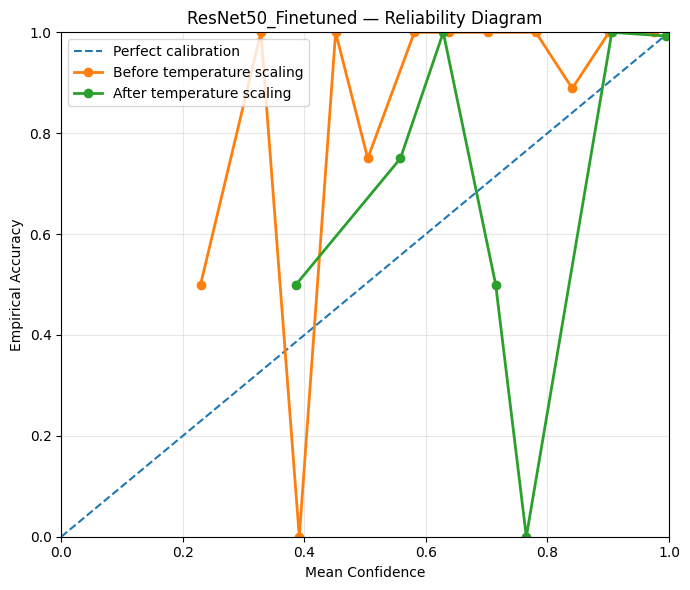

✅ Saved: /kaggle/working/phaseF_ResNet50_Finetuned_reliability_diagram.png


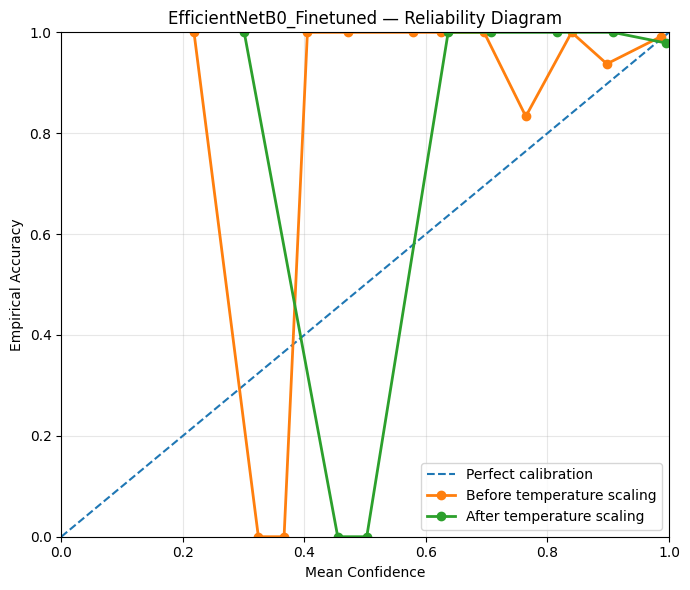

✅ Saved: /kaggle/working/phaseF_EfficientNetB0_Finetuned_reliability_diagram.png


In [13]:
# ============================================================
# CELL 13 — RELIABILITY DIAGRAMS
# One publication-ready figure per model
# ============================================================

for model_name in MODEL_OBJECTS.keys():
    before_df = uncalibrated_results[
        model_name
    ]["reliability_df"]

    after_df = calibrated_results[
        model_name
    ]["reliability_df"]

    valid_before = before_df[
        before_df["count"] > 0
    ]

    valid_after = after_df[
        after_df["count"] > 0
    ]

    plt.figure(
        figsize=(7, 6)
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    plt.plot(
        valid_before["mean_confidence"],
        valid_before["accuracy"],
        marker="o",
        linewidth=2,
        label="Before temperature scaling"
    )

    plt.plot(
        valid_after["mean_confidence"],
        valid_after["accuracy"],
        marker="o",
        linewidth=2,
        label="After temperature scaling"
    )

    plt.xlabel("Mean Confidence")
    plt.ylabel("Empirical Accuracy")
    plt.title(
        f"{model_name} — Reliability Diagram"
    )
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    save_path = (
        f"/kaggle/working/"
        f"phaseF_{model_name}_reliability_diagram.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("✅ Saved:", save_path)


In [14]:
# ============================================================
# CELL 14 — CONFIDENCE / ENTROPY ERROR ANALYSIS
# ============================================================

uncertainty_rows = []

for model_name in MODEL_OBJECTS.keys():
    labels = raw_outputs[
        model_name
    ]["test_labels"].numpy()

    for calibration_state, result in [
        ("Before", uncalibrated_results[model_name]),
        ("After", calibrated_results[model_name]),
    ]:
        pred = result["predictions"]
        conf = result["confidences"]
        entropy = result["entropy"]

        correct_mask = (
            pred == labels
        )

        incorrect_mask = ~correct_mask

        uncertainty_rows.append({
            "Model": model_name,
            "Calibration": calibration_state,

            "Correct Samples":
                int(correct_mask.sum()),

            "Incorrect Samples":
                int(incorrect_mask.sum()),

            "Mean Confidence — Correct":
                float(conf[correct_mask].mean())
                if correct_mask.any()
                else np.nan,

            "Mean Confidence — Incorrect":
                float(conf[incorrect_mask].mean())
                if incorrect_mask.any()
                else np.nan,

            "Mean Entropy — Correct":
                float(entropy[correct_mask].mean())
                if correct_mask.any()
                else np.nan,

            "Mean Entropy — Incorrect":
                float(entropy[incorrect_mask].mean())
                if incorrect_mask.any()
                else np.nan,

            "Error-detection AUROC":
                result["error_detection_auroc"],
        })

uncertainty_summary_df = pd.DataFrame(
    uncertainty_rows
)

display(
    uncertainty_summary_df.round(6)
)

UNCERTAINTY_SUMMARY_PATH = (
    "/kaggle/working/"
    "phaseF_uncertainty_summary.csv"
)

uncertainty_summary_df.to_csv(
    UNCERTAINTY_SUMMARY_PATH,
    index=False
)

print("\n✅ Saved:", UNCERTAINTY_SUMMARY_PATH)


,Model,Calibration,Correct Samples,Incorrect Samples,Mean Confidence — Correct,Mean Confidence — Incorrect,Mean Entropy — Correct,Mean Entropy — Incorrect,Error-detection AUROC
0,ResNet50_Finetuned,Before,151,6,0.883999,0.482216,0.438362,1.404908,0.931567
1,ResNet50_Finetuned,After,151,6,0.971671,0.698978,0.082441,0.795790,0.947020
2,EfficientNetB0_Finetuned,Before,150,7,0.932259,0.568837,0.271031,1.252949,0.907619
3,EfficientNetB0_Finetuned,After,150,7,0.977454,0.692623,0.077043,0.772265,0.906667



✅ Saved: /kaggle/working/phaseF_uncertainty_summary.csv


In [15]:
# ============================================================
# CELL 15 — SAVE PER-IMAGE CALIBRATION OUTPUTS
# ============================================================

sample_paths = [
    path
    for path, label in test_dataset.samples
]

for model_name in MODEL_OBJECTS.keys():
    labels = raw_outputs[
        model_name
    ]["test_labels"].numpy()

    before = uncalibrated_results[
        model_name
    ]

    after = calibrated_results[
        model_name
    ]

    output_df = pd.DataFrame({
        "image_path":
            sample_paths,

        "true_index":
            labels,

        "true_class":
            [CLASS_NAMES[i] for i in labels],

        "pred_index":
            before["predictions"],

        "pred_class":
            [
                CLASS_NAMES[i]
                for i in before["predictions"]
            ],

        "correct":
            before["predictions"] == labels,

        "confidence_before":
            before["confidences"],

        "confidence_after":
            after["confidences"],

        "entropy_before":
            before["entropy"],

        "entropy_after":
            after["entropy"],
    })

    csv_path = (
        f"/kaggle/working/"
        f"phaseF_{model_name}_per_image.csv"
    )

    output_df.to_csv(
        csv_path,
        index=False
    )

    # Preserve complete probability vectors.
    npz_path = (
        f"/kaggle/working/"
        f"phaseF_{model_name}_calibration_arrays.npz"
    )

    np.savez_compressed(
        npz_path,
        image_paths=np.asarray(sample_paths),
        class_names=np.asarray(CLASS_NAMES),
        y_true=labels,
        y_pred=before["predictions"],
        probabilities_before=before["probabilities"],
        probabilities_after=after["probabilities"],
        confidence_before=before["confidences"],
        confidence_after=after["confidences"],
        entropy_before=before["entropy"],
        entropy_after=after["entropy"],
        temperature=np.asarray(
            [temperatures[model_name]],
            dtype=np.float64
        ),
    )

    print(model_name)
    print("  ✅ Per-image CSV:", csv_path)
    print("  ✅ Probability archive:", npz_path)


ResNet50_Finetuned
  ✅ Per-image CSV: /kaggle/working/phaseF_ResNet50_Finetuned_per_image.csv
  ✅ Probability archive: /kaggle/working/phaseF_ResNet50_Finetuned_calibration_arrays.npz
EfficientNetB0_Finetuned
  ✅ Per-image CSV: /kaggle/working/phaseF_EfficientNetB0_Finetuned_per_image.csv
  ✅ Probability archive: /kaggle/working/phaseF_EfficientNetB0_Finetuned_calibration_arrays.npz


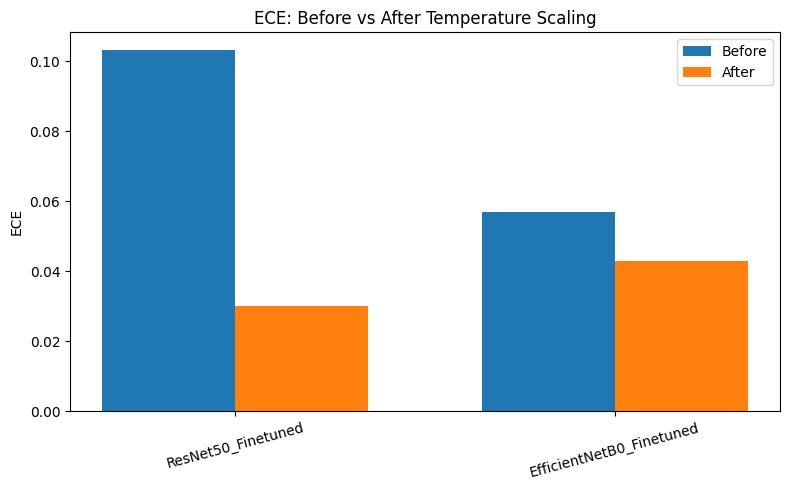

✅ Saved: /kaggle/working/phaseF_ece_comparison.png


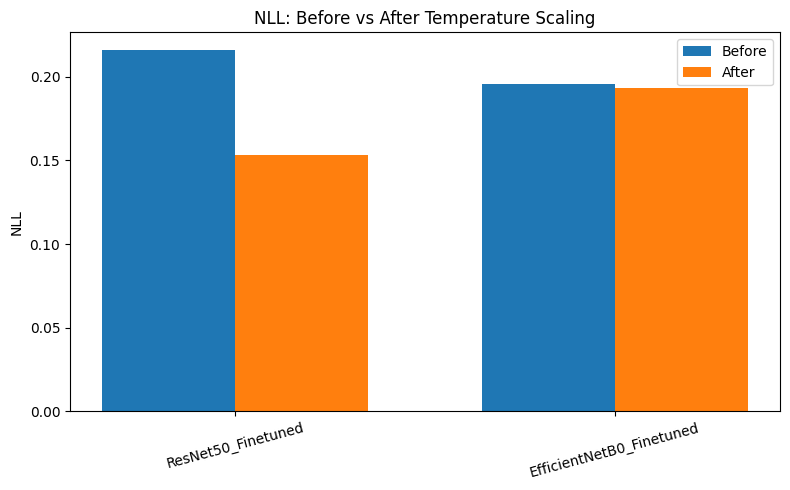

✅ Saved: /kaggle/working/phaseF_nll_comparison.png


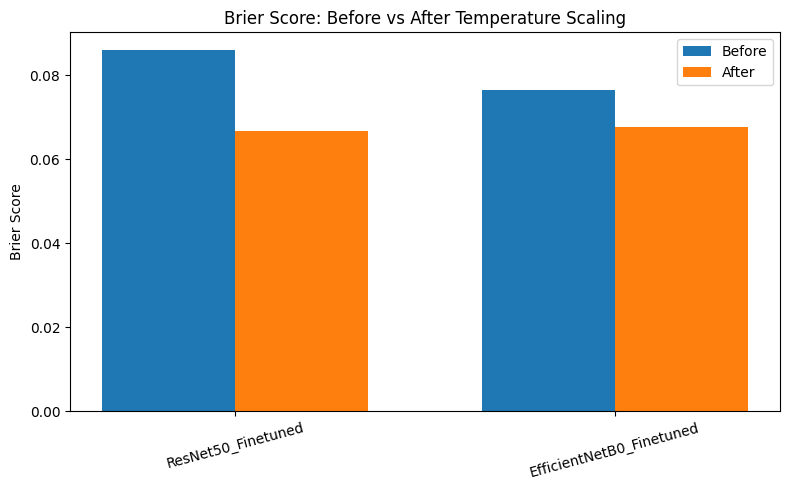

✅ Saved: /kaggle/working/phaseF_brier_score_comparison.png


In [16]:
# ============================================================
# CELL 16 — CALIBRATION METRIC COMPARISON FIGURES
# ============================================================

metric_pairs = [
    ("ECE Before", "ECE After", "ECE"),
    ("NLL Before", "NLL After", "NLL"),
    ("Brier Before", "Brier After", "Brier Score"),
]

for before_col, after_col, metric_name in metric_pairs:
    plot_df = calibration_summary_df[
        ["Model", before_col, after_col]
    ].copy()

    x = np.arange(
        len(plot_df)
    )

    width = 0.35

    plt.figure(
        figsize=(8, 5)
    )

    plt.bar(
        x - width / 2,
        plot_df[before_col],
        width,
        label="Before"
    )

    plt.bar(
        x + width / 2,
        plot_df[after_col],
        width,
        label="After"
    )

    plt.xticks(
        x,
        plot_df["Model"],
        rotation=15
    )

    plt.ylabel(metric_name)
    plt.title(
        f"{metric_name}: Before vs After Temperature Scaling"
    )
    plt.legend()
    plt.tight_layout()

    safe_name = (
        metric_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    save_path = (
        f"/kaggle/working/"
        f"phaseF_{safe_name}_comparison.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("✅ Saved:", save_path)


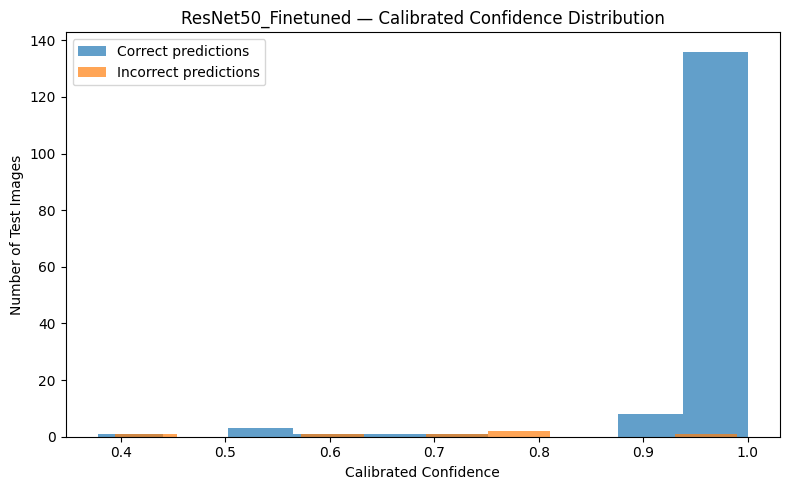

✅ Saved: /kaggle/working/phaseF_ResNet50_Finetuned_confidence_distribution.png


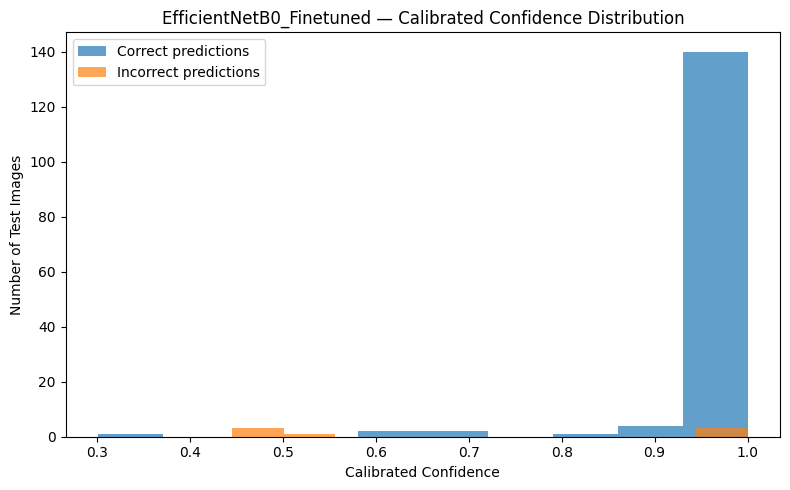

✅ Saved: /kaggle/working/phaseF_EfficientNetB0_Finetuned_confidence_distribution.png


In [17]:
# ============================================================
# CELL 17 — CONFIDENCE DISTRIBUTION FIGURES
# ============================================================

for model_name in MODEL_OBJECTS.keys():
    labels = raw_outputs[
        model_name
    ]["test_labels"].numpy()

    result = calibrated_results[
        model_name
    ]

    correct_mask = (
        result["predictions"] == labels
    )

    incorrect_mask = ~correct_mask

    plt.figure(
        figsize=(8, 5)
    )

    if correct_mask.any():
        plt.hist(
            result["confidences"][correct_mask],
            bins=10,
            alpha=0.7,
            label="Correct predictions"
        )

    if incorrect_mask.any():
        plt.hist(
            result["confidences"][incorrect_mask],
            bins=10,
            alpha=0.7,
            label="Incorrect predictions"
        )

    plt.xlabel("Calibrated Confidence")
    plt.ylabel("Number of Test Images")
    plt.title(
        f"{model_name} — Calibrated Confidence Distribution"
    )
    plt.legend()
    plt.tight_layout()

    save_path = (
        f"/kaggle/working/"
        f"phaseF_{model_name}_confidence_distribution.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("✅ Saved:", save_path)


In [18]:
# ============================================================
# CELL 18 — PHASE F METADATA
# ============================================================

phaseF_metadata = {
    "phase":
        "Phase F — Calibration & Uncertainty Evaluation",

    "seed":
        SEED,

    "validation_images":
        len(val_dataset),

    "test_images":
        len(test_dataset),

    "num_classes":
        NUM_CLASSES,

    "image_size":
        IMG_SIZE,

    "ece_bins":
        ECE_BINS,

    "models": [
        "ResNet50_Finetuned",
        "EfficientNetB0_Finetuned",
    ],

    "temperature_scaling_fit_set":
        "Validation only",

    "locked_test_used_for_temperature_fit":
        False,

    "neural_network_training_performed":
        False,

    "temperature_values": {
        model_name: float(T)
        for model_name, T in temperatures.items()
    },

    "metrics": [
        "ECE",
        "NLL",
        "Multiclass Brier Score",
        "Mean Confidence",
        "Confidence Gap",
        "Predictive Entropy",
        "Error-detection AUROC",
    ],

    "device":
        str(DEVICE),

    "gpu":
        (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        ),
}

METADATA_PATH = (
    "/kaggle/working/"
    "phaseF_metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as f:
    json.dump(
        phaseF_metadata,
        f,
        indent=2
    )

print(json.dumps(
    phaseF_metadata,
    indent=2
))

print("\n✅ Saved:", METADATA_PATH)


{
  "phase": "Phase F \u2014 Calibration & Uncertainty Evaluation",
  "seed": 42,
  "validation_images": 161,
  "test_images": 157,
  "num_classes": 14,
  "image_size": 224,
  "ece_bins": 15,
  "models": [
    "ResNet50_Finetuned",
    "EfficientNetB0_Finetuned"
  ],
  "temperature_scaling_fit_set": "Validation only",
  "locked_test_used_for_temperature_fit": false,
  "neural_network_training_performed": false,
  "temperature_values": {
    "ResNet50_Finetuned": 0.4453571140766144,
    "EfficientNetB0_Finetuned": 0.5874667167663574
  },
  "metrics": [
    "ECE",
    "NLL",
    "Multiclass Brier Score",
    "Mean Confidence",
    "Confidence Gap",
    "Predictive Entropy",
    "Error-detection AUROC"
  ],
  "device": "cuda",
  "gpu": "Tesla T4"
}

✅ Saved: /kaggle/working/phaseF_metadata.json


In [19]:
# ============================================================
# CELL 19 — CREATE COMPLETE PHASE-F ARTIFACT ZIP
# ============================================================

PHASE_F_ZIP = (
    "/kaggle/working/"
    "AquaPlant_PhaseF_Calibration_Uncertainty_Artifacts.zip"
)

files_to_backup = []

for filename in os.listdir(
    "/kaggle/working"
):
    full_path = os.path.join(
        "/kaggle/working",
        filename
    )

    if not os.path.isfile(
        full_path
    ):
        continue

    if filename.startswith(
        "phaseF_"
    ) and filename.lower().endswith(
        (
            ".csv",
            ".png",
            ".json",
            ".npz",
        )
    ):
        files_to_backup.append(
            full_path
        )

with zipfile.ZipFile(
    PHASE_F_ZIP,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:
    for file_path in files_to_backup:
        zipf.write(
            file_path,
            arcname=os.path.basename(
                file_path
            )
        )

with zipfile.ZipFile(
    PHASE_F_ZIP,
    "r"
) as zipf:
    bad_file = zipf.testzip()
    zip_contents = zipf.namelist()

assert bad_file is None

print("=" * 76)
print("PHASE F FINAL BACKUP")
print("=" * 76)

print("ZIP:")
print(PHASE_F_ZIP)

print("\nFiles included:", len(zip_contents))

for file in sorted(zip_contents):
    print(" -", file)

print(
    "\nZIP size:",
    f"{os.path.getsize(PHASE_F_ZIP) / (1024 ** 2):.2f} MB"
)

print("\n✅ ZIP integrity check PASSED")
print("✅ PHASE F CALIBRATION & UNCERTAINTY EVALUATION COMPLETE")
print("✅ Download AquaPlant_PhaseF_Calibration_Uncertainty_Artifacts.zip")


PHASE F FINAL BACKUP
ZIP:
/kaggle/working/AquaPlant_PhaseF_Calibration_Uncertainty_Artifacts.zip

Files included: 19
 - phaseF_EfficientNetB0_Finetuned_calibration_arrays.npz
 - phaseF_EfficientNetB0_Finetuned_confidence_distribution.png
 - phaseF_EfficientNetB0_Finetuned_per_image.csv
 - phaseF_EfficientNetB0_Finetuned_reliability_after.csv
 - phaseF_EfficientNetB0_Finetuned_reliability_before.csv
 - phaseF_EfficientNetB0_Finetuned_reliability_diagram.png
 - phaseF_ResNet50_Finetuned_calibration_arrays.npz
 - phaseF_ResNet50_Finetuned_confidence_distribution.png
 - phaseF_ResNet50_Finetuned_per_image.csv
 - phaseF_ResNet50_Finetuned_reliability_after.csv
 - phaseF_ResNet50_Finetuned_reliability_before.csv
 - phaseF_ResNet50_Finetuned_reliability_diagram.png
 - phaseF_brier_score_comparison.png
 - phaseF_calibration_summary.csv
 - phaseF_class_mapping.json
 - phaseF_ece_comparison.png
 - phaseF_metadata.json
 - phaseF_nll_comparison.png
 - phaseF_uncertainty_summary.csv

ZIP size: 0.88

## Final interpretation rule

When reporting Phase F:

- **Accuracy and Macro-F1 should remain unchanged after temperature scaling.**
- Better calibration is indicated by **lower ECE, lower NLL, and lower Brier Score**.
- A lower absolute confidence gap indicates that average confidence better matches observed accuracy.
- For uncertainty analysis, incorrect predictions should ideally have **higher predictive entropy** than correct predictions.
- Error-detection AUROC above 0.5 means uncertainty has some ability to distinguish errors from correct predictions.

Do not claim temperature scaling improved classification accuracy; it calibrates confidence, not class decisions.